<a href="https://colab.research.google.com/github/jiaforsstrom-jf/Wearable-Tech-2025-Balancing-Market-Opportunity-with-Technical-Due-Diligence./blob/main/Wearable%20tech%202025%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 1. Bring in the tools (libraries)
import pandas as pd     #For handling data tables
import seaborn as sns   #For making pretty charts
import matplotlib.pyplot as plt # For fine-tuning charts

# 2. Load the data

df = pd.read_csv('/content/sample_data/wearable_health_devices_performance_upto_26june2025.csv')

# 3. The "Auditor's First Look" - Run this to see if the data loaded correctly

print ("---Data Header---")
print (df.head()) # shows first 5 rows

print ("\n--- Column Info ---")
print (df.info()) #shows colunm names and if data is missing





---Data Header---
    Test_Date              Device_Name    Brand            Model  \
0  2025-06-01         Fitbit Inspire 4   Fitbit        Inspire 4   
1  2025-06-01         Apple Watch SE 3    Apple       Watch SE 3   
2  2025-06-01           Fitbit Versa 4   Fitbit          Versa 4   
3  2025-06-01         Polar Vantage V3    Polar       Vantage V3   
4  2025-06-01  Samsung Galaxy Watch FE  Samsung  Galaxy Watch FE   

          Category  Price_USD  Battery_Life_Hours  \
0  Fitness Tracker     141.74               129.9   
1       Smartwatch     834.64                26.5   
2     Sports Watch     145.34               161.2   
3       Smartwatch     349.53                69.4   
4       Smartwatch     502.43                39.7   

   Heart_Rate_Accuracy_Percent  Step_Count_Accuracy_Percent  \
0                        89.69                        93.03   
1                        95.92                        98.20   
2                        92.24                        96.81   
3 

In [5]:
# Part 1. Create the 'Clinical Trust Index'
# Define strategic weights here:
# Heart_Rate_Accuracy_Percent = 0.7
# User_Satisfaction_Rating = 0.3
# by turing ratings into a 0-100 scale by multiplying by 10
df ['Clinical_Trust_Index'] = (
    (df['Heart_Rate_Accuracy_Percent'] * 0.7) +
    (df['User_Satisfaction_Rating'] *10 * 0.3)
)
# See which brands have the highest trust
brand_rank = df.groupby ('Brand') ['Clinical_Trust_Index']. mean() .sort_values (ascending = False)
print (brand_rank)

# Cross_referencing Tableau Categories with Technical Trust
category_audit = df.groupby ('Category') .agg({
    'Clinical_Trust_Index': 'mean',
    'Price_USD': 'mean'
}).sort_values (by = 'Clinical_Trust_Index', ascending = False)
print ("Stratgeic Category Audit : ")
print (category_audit)

Brand
Garmin      91.764630
Apple       91.737144
Samsung     91.512346
Huawei      91.356751
Withings    90.715991
Polar       90.621992
Amazfit     87.898741
Fitbit      87.369262
Oura        86.916364
WHOOP       82.911926
Name: Clinical_Trust_Index, dtype: float64
Stratgeic Category Audit : 
                 Clinical_Trust_Index   Price_USD
Category                                         
Smartwatch                  91.082480  429.944146
Sports Watch                90.185384  362.416647
Smart Ring                  86.916364  426.072987
Fitness Tracker             86.184165  197.510294
Fitness Band                82.911926   30.000000


In [ ]:
# I define a 'Floor' (Minimum Requirement)
accuracy_floor = 95.0 # In %

# I filter the dataframe to only include reliable devices
reliable_df = df[df['Heart_Rate_Accuracy_Percent'] >= accuracy_floor]

# Now let's see how many devices each brand has left in the 'Reliable' category
reliable_counts = reliable_df['Brand'].value_counts()
print("Number of Clinically Reliable Models by Brand:")
print(reliable_counts)

Number of Clinically Reliable Models by Brand:
Brand
Samsung     138
Apple       133
Garmin      125
Polar       123
Withings    109
Huawei      105
Amazfit      95
Fitbit       54
Name: count, dtype: int64


/tmp/ipykernel_13859/1466156987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_rank.values, y= brand_rank.index, palette= 'viridis')


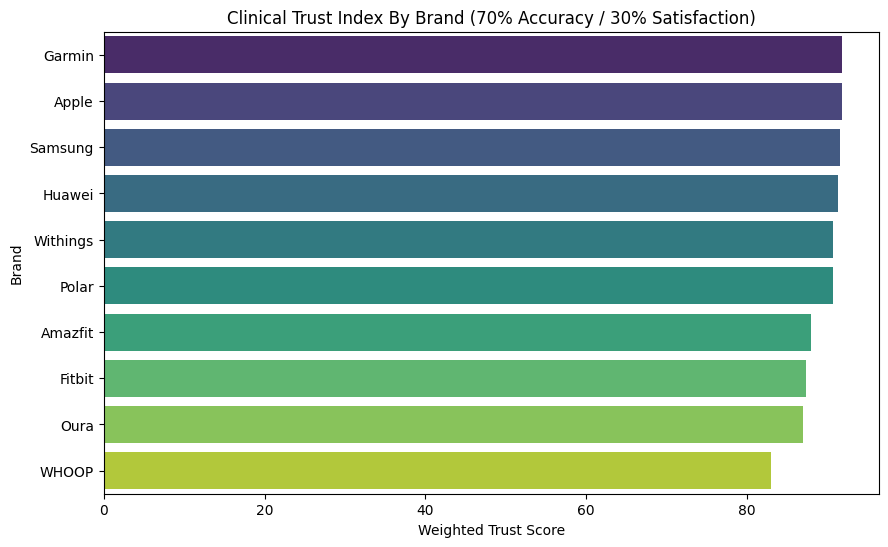

In [ ]:
#Create a bar chart using Seaborn
plt.figure (figsize= (10, 6)) #Make the chart a nice size
sns.barplot(x=brand_rank.values, y= brand_rank.index, palette= 'viridis')

#Labels and Title
plt.title ('Clinical Trust Index By Brand (70% Accuracy / 30% Satisfaction)')
plt.xlabel ('Weighted Trust Score')
plt.ylabel ('Brand')

plt.show()

In [ ]:
# A new tool for interactive charts
import plotly.express as px

fig = px.scatter (df, x= "Price_USD", y= "Clinical_Trust_Index", color = "Category",
                  hover_name ="Device_Name",
                  title  = "Market Analysis : Price vs. Clincal Reliablity", labels ={"Price_USD": "Price (USD)", "Clinical_Trust_Index": "Clinical Trust Index (70/30)"},
                  trendline ="ols")  # Adds a 'line of best fit' to see the general trend

fig.show()

In [7]:
#Part 2: The Engineering Efficiency Audit(Hardware ROI)
#Tableau identified a "Trap" in Sports Watches. Python proves this is due to Hardware Bloat—adding more sensors is no longer delivering higher trust or performance.
#Calculating 'Trust per Sensor' (Hardware Efficiency)

df['Sensor_Efficiency'] = df['Clinical_Trust_Index'] / df['Health_Sensors_Count']
efficiency_audit = df.groupby ('Category') ['Sensor_Efficiency']. mean() .sort_values(ascending= False)

# Correlation check: Do more sensors hurt battery life?
correlation = df['Health_Sensors_Count'].corr(df['Battery_Life_Hours'])

print (f"Sensor-to-Battery Correlation: {correlation: .2f}")
print ("\nHardware Efficiency by Category:")
print (efficiency_audit)

Sensor-to-Battery Correlation: -0.15

Hardware Efficiency by Category:
Category
Fitness Band       26.970198
Smart Ring         20.770953
Sports Watch       12.537204
Fitness Tracker    12.166556
Smartwatch          8.248501
Name: Sensor_Efficiency, dtype: float64


In [10]:
#Tableau showed that iOS-locked users are the most satisfied. Python investigates if we are paying for Technical Lead or Brand Illusion
# Comparing Technical Accuracy vs. User Perception across Ecosystems

ecosystem_audit = df.groupby ('App_Ecosystem_Support'). agg({
    'Heart_Rate_Accuracy_Percent': 'mean',
    'User_Satisfaction_Rating': 'mean',
    'Price_USD': 'mean'
})
print ("Ecosystem Audit:")
print (ecosystem_audit)

Ecosystem Audit:
                       Heart_Rate_Accuracy_Percent  User_Satisfaction_Rating  \
App_Ecosystem_Support                                                          
Android/iOS                              93.031734                  7.965806   
Cross-platform                           93.461839                  7.880307   
iOS                                      95.026381                  8.406226   

                        Price_USD  
App_Ecosystem_Support              
Android/iOS            335.241956  
Cross-platform         341.912920  
iOS                    525.029494  


In [ ]:
import plotly.express as px

# Efficiency Visual
fig_eff = px.bar(efficiency_audit, title="Hardware ROI: Clinical Trust per Sensor",
                 labels={'value':'Efficiency Score', 'index':'Category'}, color=efficiency_audit.values)
fig_eff.show()

# Ecosystem Visual
fig_eco = px.bar(ecosystem_audit, barmode='group',
                 title="The Ecosystem Tax: Technical Accuracy vs. Perception",
                 labels={'value':'Score', 'App_Ecosystem_Support':'Platform'})
fig_eco.show()

In [16]:
# Efficiency Visual
fig_eff = px.bar(efficiency_audit, title="Hardware ROI: Clinical Trust per Sensor",
                 labels={'value':'Efficiency Score', 'index':'Category'}, color=efficiency_audit.values)
fig_eff.show()

# Ecosystem Visual
fig_eco = px.bar(ecosystem_audit, barmode='group',
                 title="The Ecosystem Tax: Technical Accuracy vs. Perception",
                 labels={'value':'Score', 'App_Ecosystem_Support':'Platform'})
fig_eco.show()



import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a subplot with 2 y-axes
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add Price as a Bar Chart
fig.add_trace(
    go.Bar(x=ecosystem_audit.index, y=ecosystem_audit['Price_USD'], name="Price (USD)", marker_color='lightgrey'),
    secondary_y=False,
)

# Add Accuracy as a Line Chart
fig.add_trace(
    go.Scatter(x=ecosystem_audit.index, y=ecosystem_audit['Heart_Rate_Accuracy_Percent'],
               name="Technical Accuracy %", mode='lines+markers', marker_color='blue'),
    secondary_y=True,
)

# Add Satisfaction as a Line Chart
fig.add_trace(
    go.Scatter(x=ecosystem_audit.index, y=ecosystem_audit['User_Satisfaction_Rating'] * 10,
               name="Satisfaction Score (Scaled x10)", mode='lines+markers', marker_color='red'),
    secondary_y=True,
)

# Set titles
fig.update_layout(title_text="<b>The Apple Tax Audit:</b> Price Premium vs. Technical Gain")
fig.update_yaxes(title_text="Price in USD", secondary_y=False)
fig.update_yaxes(title_text="Performance Metrics", secondary_y=True, range=[75, 100]) # Zoom in on the 75-100 range

fig.show()